# Sistema Fuzzy para Risco de Evasão Acadêmica

## Apoio interpretável à intervenção durante a trajetória acadêmica

Este estudo investiga se quatro sistemas Mamdani, com regras aprendidas automaticamente, conseguem organizar sinais acadêmicos, sociais e demográficos em um risco contínuo de evasão entre 0 e 100. O sistema não é uma triagem de admissão: ele pretende apoiar uma ação humana antes que a evasão aconteça.

## 1. Preparação e protocolo

A classe `Enrolled` é removida. Os estudantes restantes são separados de forma estratificada em 70% treino, 15% validação e 15% teste. O treino aprende as regras, a validação seleciona o limiar por F2 e o teste é reservado para a avaliação final.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from typing import Sequence

sys.path.insert(0, os.path.abspath('.'))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from src import data, evaluate
from src.experiment import ExperimentResult, export_experiment, run_experiment

%matplotlib inline
pd.set_option('display.max_colwidth', 140)
OUTPUT_DIR = Path('outputs')

def show_images(paths: Sequence[Path], *, width: int = 760) -> None:
    for path in paths:
        display(Image(filename=str(path), width=width))

In [2]:
raw = data.load_raw(use_cache=True)
students = data.build_features(raw)
experiment: ExperimentResult = run_experiment(students, random_state=42, folds=5, bootstrap_iterations=1000)
export_experiment(experiment, OUTPUT_DIR)

split_summary = pd.DataFrame({
    'particao': ['Treino', 'Validacao', 'Teste'],
    'n': [len(experiment.split.train), len(experiment.split.validation), len(experiment.split.test)],
    'taxa_dropout': [
        experiment.split.train['y_true'].mean(),
        experiment.split.validation['y_true'].mean(),
        experiment.split.test['y_true'].mean(),
    ],
})
split_summary

,particao,n,taxa_dropout
0,Treino,2541,0.391578
1,Validacao,544,0.391544
2,Teste,545,0.390826


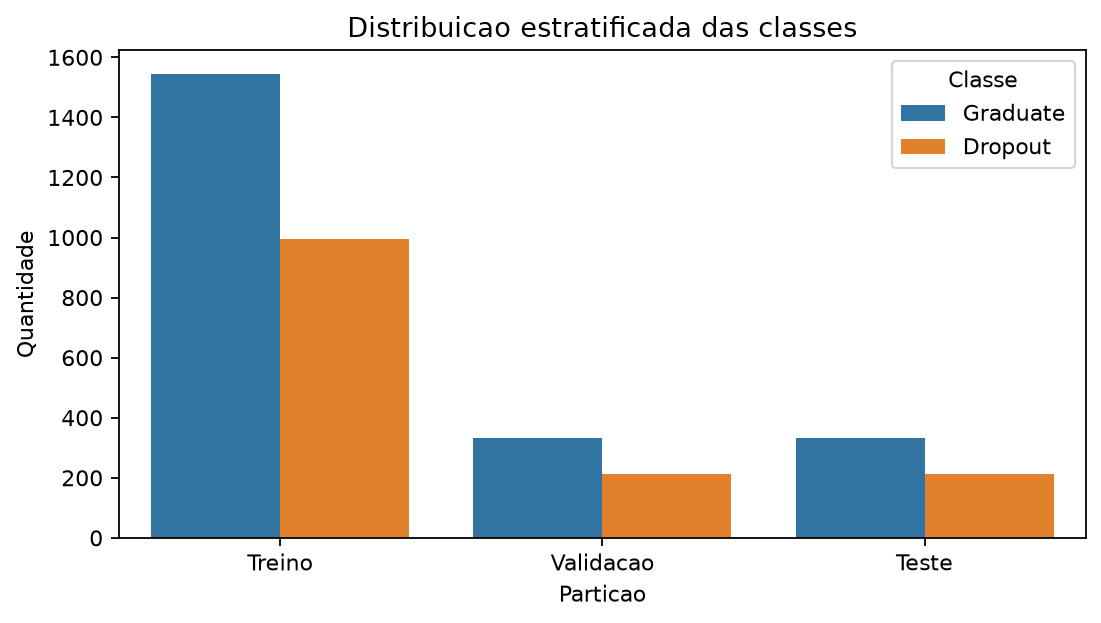

In [3]:
show_images([OUTPUT_DIR / 'split_distribution.png'])

## 2. Arquitetura fuzzy hierárquica

Os subsistemas acadêmico, social/financeiro e demográfico produzem riscos intermediários. O sistema final aprende a combiná-los usando predições *out-of-fold*, evitando que ele seja treinado com riscos produzidos pelos mesmos exemplos usados no ajuste dos subsistemas.

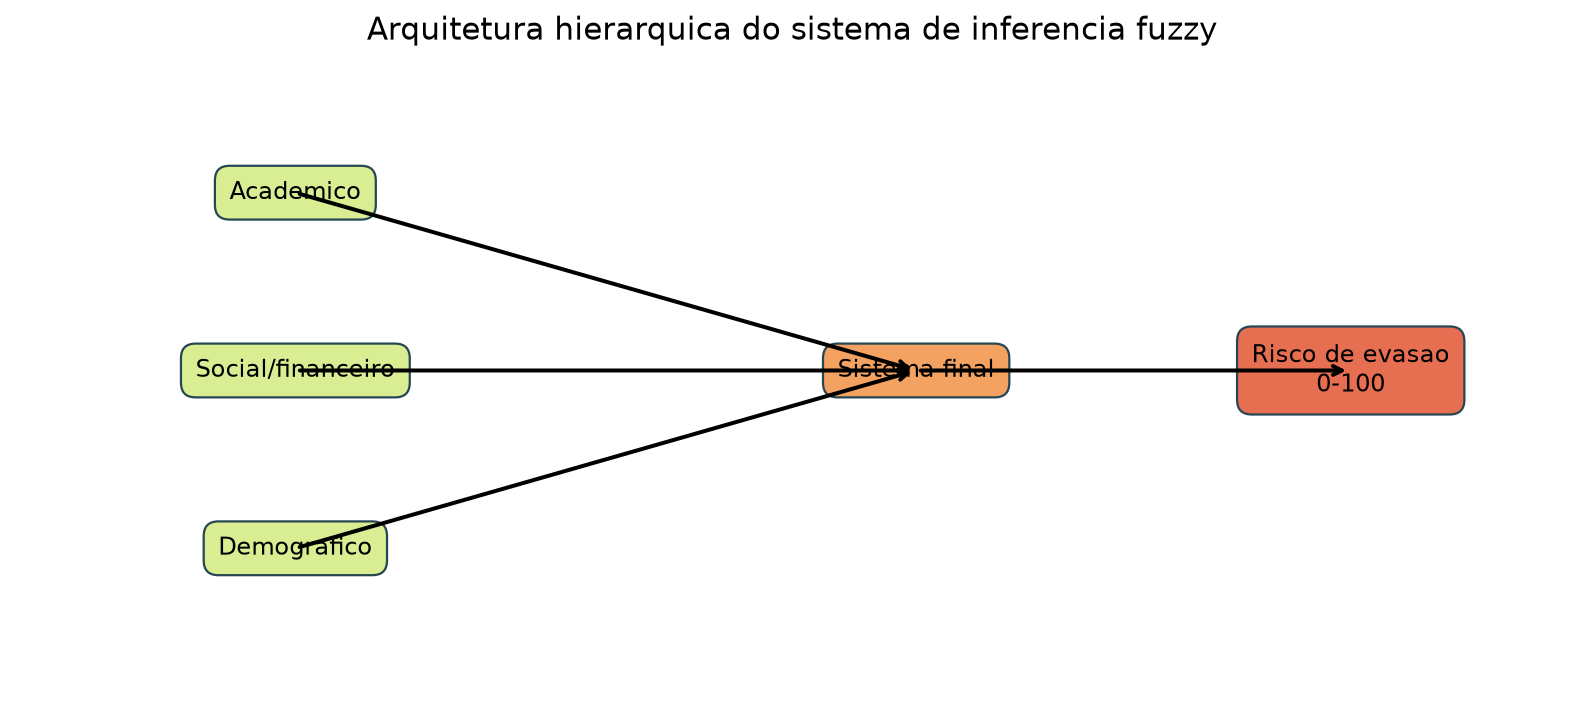

In [4]:
show_images([OUTPUT_DIR / 'system_diagram.png'])

## 3. Pertinência, regras aprendidas e centroide

As funções de entrada preservam faixas linguísticas definidas por domínio. A base de regras é induzida no treino por uma grade fuzzy ponderada. A inferência usa mínimo, máximo e defuzzificação pelo centroide da área de saída agregada.

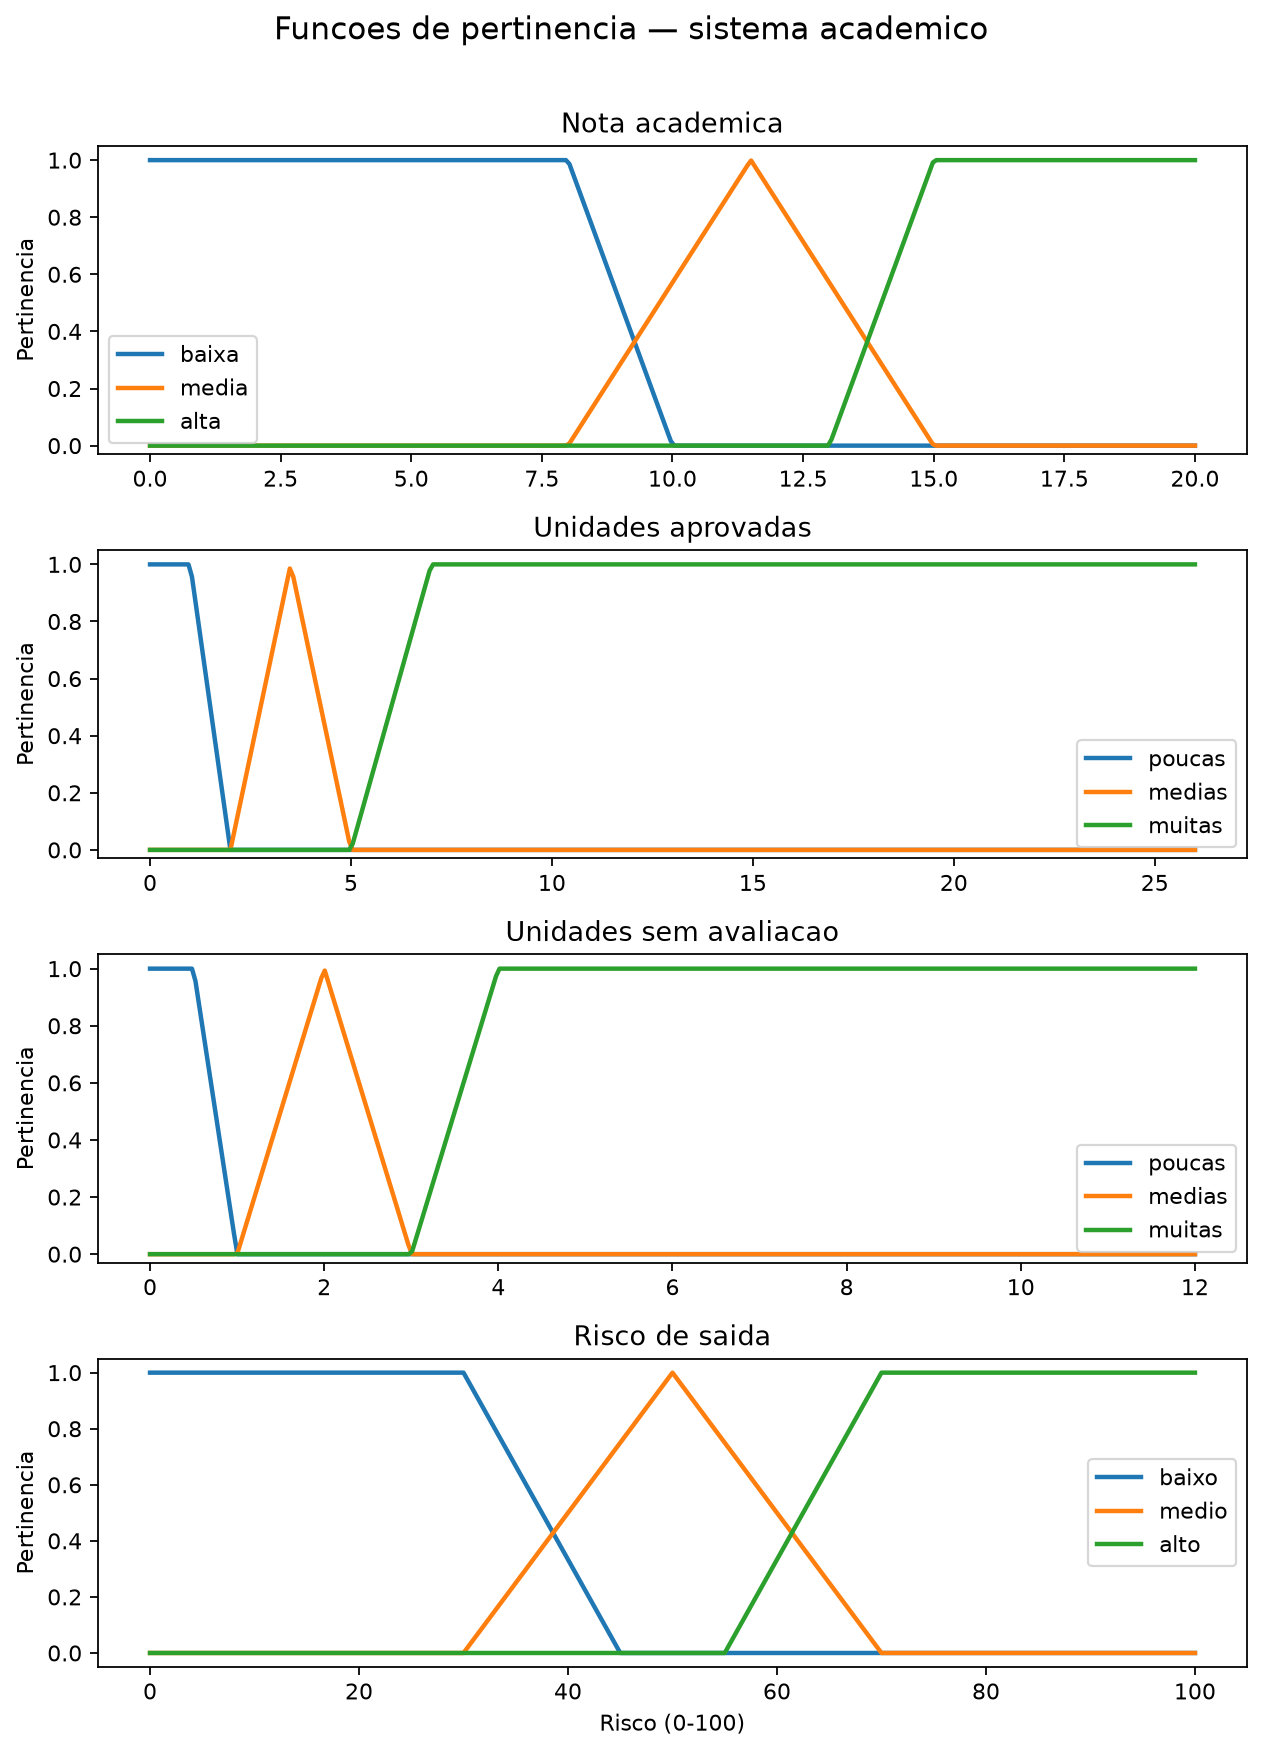

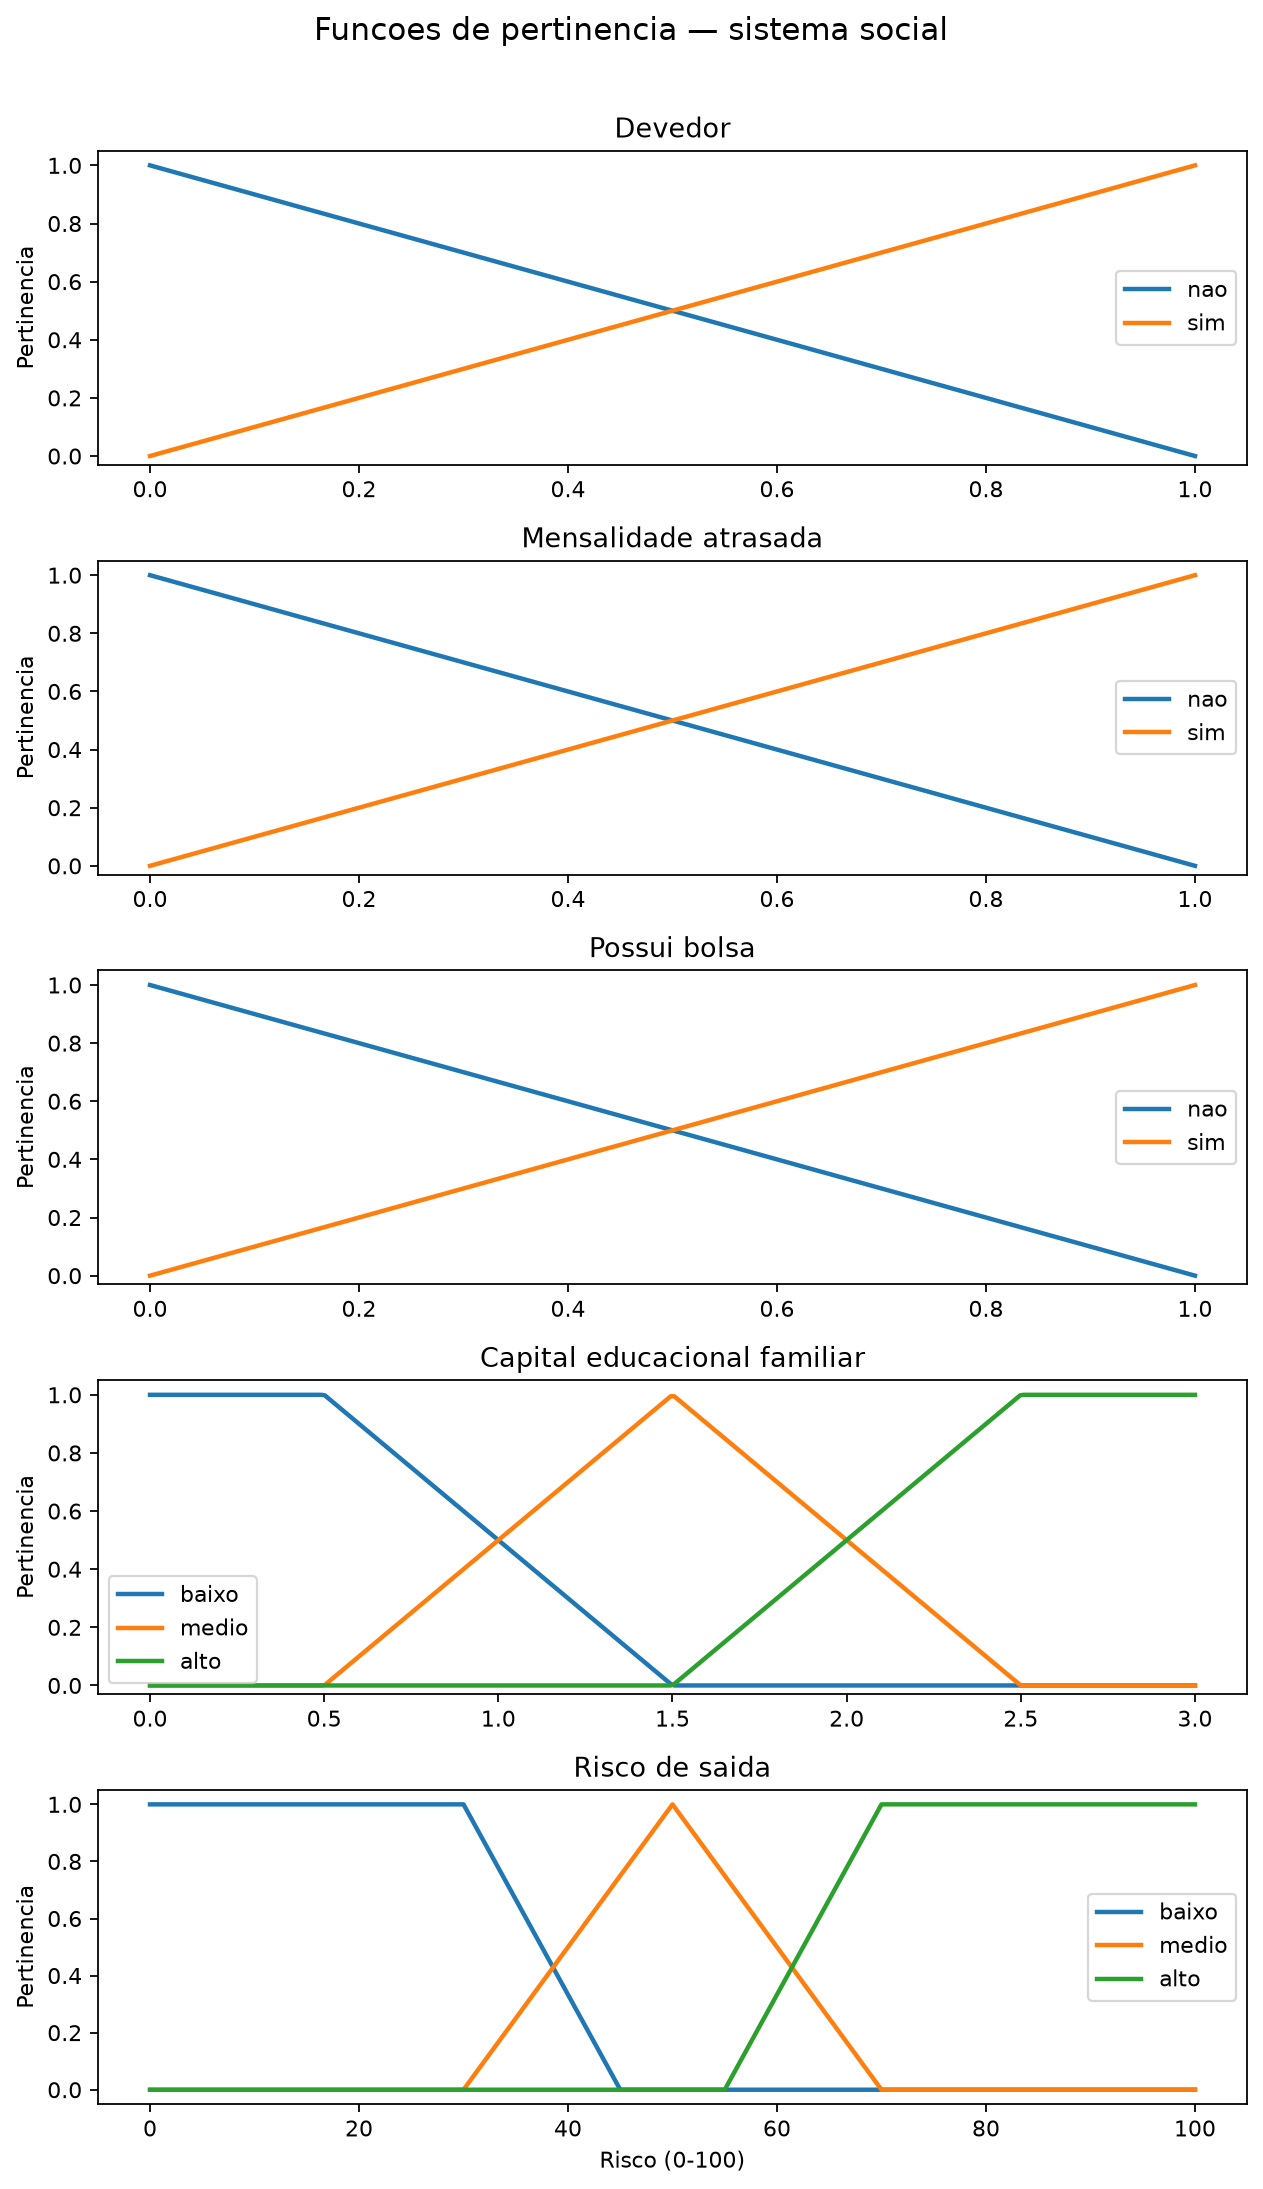

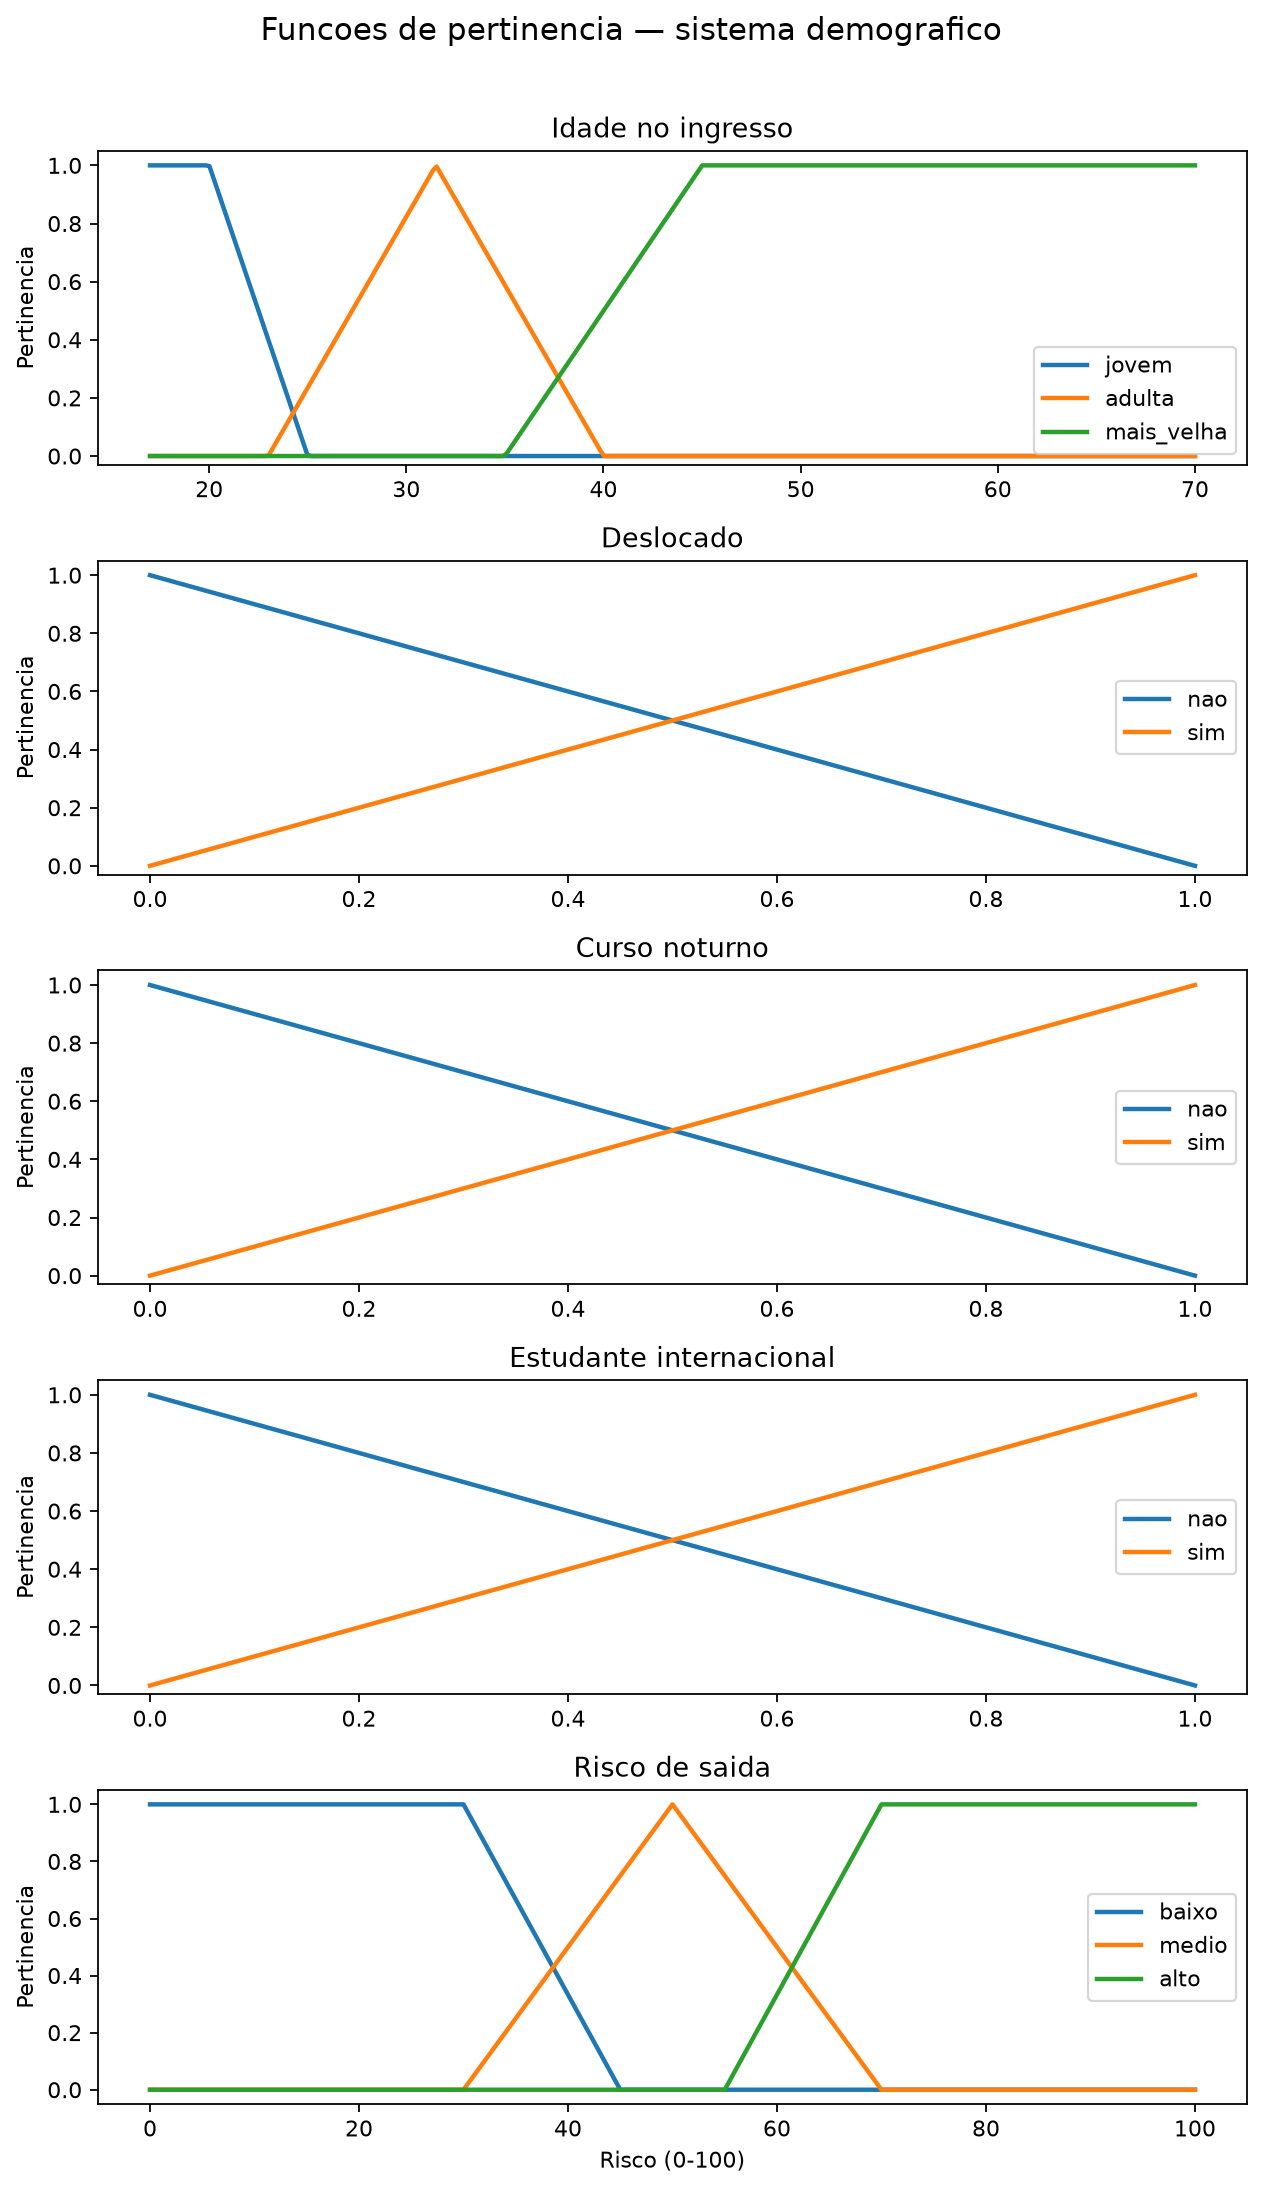

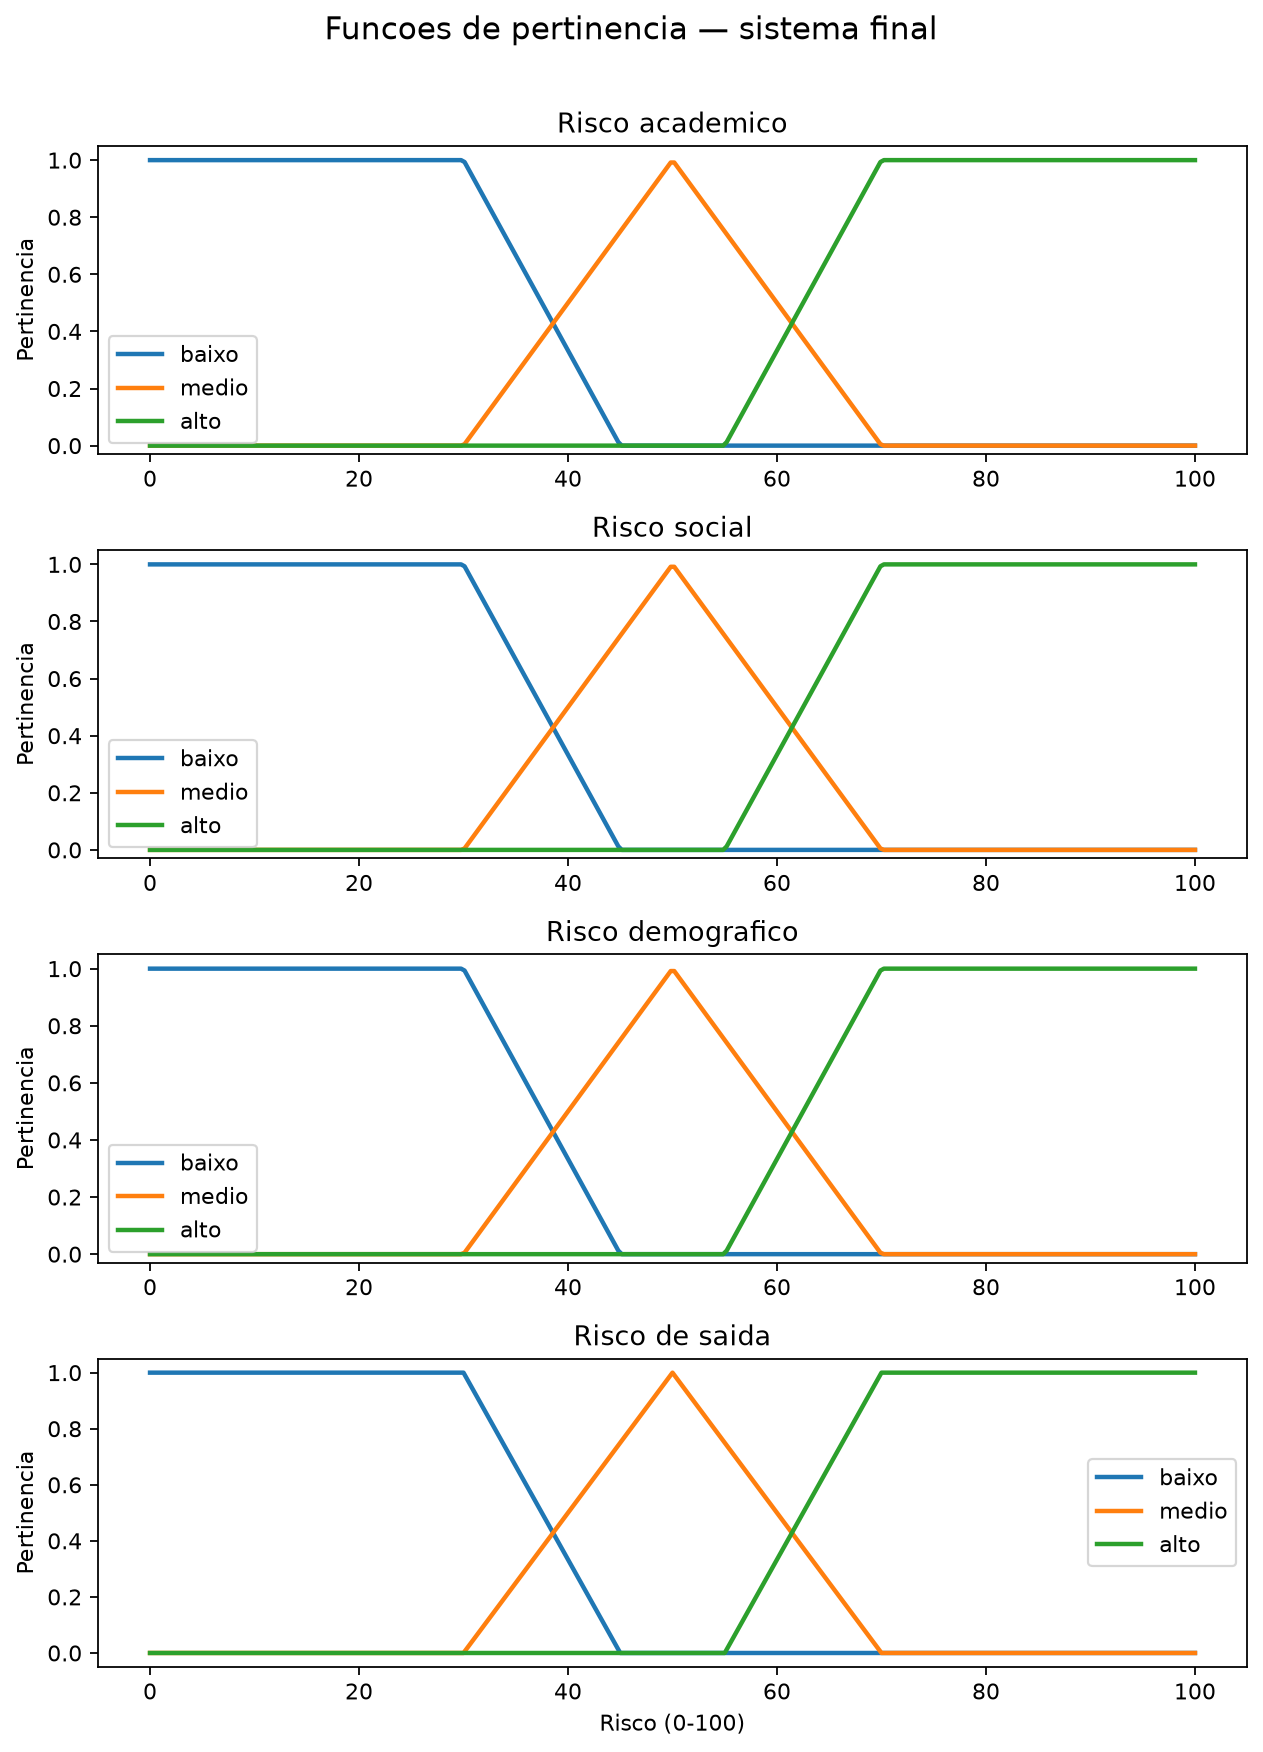

In [5]:
show_images([
    OUTPUT_DIR / 'memberships_academico.png',
    OUTPUT_DIR / 'memberships_social.png',
    OUTPUT_DIR / 'memberships_demografico.png',
    OUTPUT_DIR / 'memberships_final.png',
])

In [6]:
for system_name in ('academico', 'social', 'demografico', 'final'):
    rules = pd.read_csv(OUTPUT_DIR / f'rules_{system_name}.csv')
    print(f'\nSistema {system_name}: {len(rules)} regras retidas')
    display(rules.sort_values(['support', 'weight'], ascending=False).head(10))


Sistema academico: 15 regras retidas


,rule,consequent,support,estimated_risk,weight
8,SE nota_academica=media E aprovadas=muitas E sem_avaliacao=poucas ENTAO risco=baixo,baixo,532.710793,10.948053,1.000000
0,SE nota_academica=baixa E aprovadas=poucas E sem_avaliacao=poucas ENTAO risco=alto,alto,473.452222,89.540835,1.000000
14,SE nota_academica=alta E aprovadas=muitas E sem_avaliacao=poucas ENTAO risco=baixo,baixo,227.885668,7.712789,1.000000
6,SE nota_academica=media E aprovadas=medias E sem_avaliacao=poucas ENTAO risco=alto,alto,183.815204,66.004505,0.733634
4,SE nota_academica=media E aprovadas=poucas E sem_avaliacao=poucas ENTAO risco=alto,alto,21.254603,88.413044,1.000000
12,SE nota_academica=alta E aprovadas=medias E sem_avaliacao=poucas ENTAO risco=medio,medio,10.747540,49.477833,0.973892
2,SE nota_academica=baixa E aprovadas=poucas E sem_avaliacao=muitas ENTAO risco=alto,alto,9.848333,79.512115,1.000000
1,SE nota_academica=baixa E aprovadas=poucas E sem_avaliacao=medias ENTAO risco=alto,alto,9.000000,78.270647,1.000000
7,SE nota_academica=media E aprovadas=medias E sem_avaliacao=medias ENTAO risco=medio,medio,8.922630,54.848136,0.757593
3,SE nota_academica=baixa E aprovadas=medias E sem_avaliacao=poucas ENTAO risco=alto,alto,5.564246,68.048427,0.869895



Sistema social: 24 regras retidas


,rule,consequent,support,estimated_risk,weight
1,SE debtor=nao E tuition_late=nao E scholarship=nao E capital_educacional=medio ENTAO risco=baixo,baixo,686.5,37.087186,0.527521
0,SE debtor=nao E tuition_late=nao E scholarship=nao E capital_educacional=baixo ENTAO risco=medio,medio,405.0,43.404364,0.670218
4,SE debtor=nao E tuition_late=nao E scholarship=sim E capital_educacional=medio ENTAO risco=baixo,baixo,376.0,12.062438,1.000000
2,SE debtor=nao E tuition_late=nao E scholarship=nao E capital_educacional=alto ENTAO risco=baixo,baixo,343.5,33.416898,0.772207
3,SE debtor=nao E tuition_late=nao E scholarship=sim E capital_educacional=baixo ENTAO risco=baixo,baixo,192.5,10.105261,1.000000
7,SE debtor=nao E tuition_late=sim E scholarship=nao E capital_educacional=medio ENTAO risco=alto,alto,80.5,91.178819,1.000000
19,SE debtor=sim E tuition_late=sim E scholarship=nao E capital_educacional=medio ENTAO risco=alto,alto,74.0,91.085937,1.000000
5,SE debtor=nao E tuition_late=nao E scholarship=sim E capital_educacional=alto ENTAO risco=baixo,baixo,70.5,15.838266,1.000000
6,SE debtor=nao E tuition_late=sim E scholarship=nao E capital_educacional=baixo ENTAO risco=alto,alto,60.0,94.550601,1.000000
13,SE debtor=sim E tuition_late=nao E scholarship=nao E capital_educacional=medio ENTAO risco=medio,medio,44.5,56.480587,0.675971



Sistema demografico: 18 regras retidas


,rule,consequent,support,estimated_risk,weight
3,SE idade=jovem E deslocado=sim E noturno=nao E internacional=nao ENTAO risco=baixo,baixo,1093.200000,28.406291,1.000000
0,SE idade=jovem E deslocado=nao E noturno=nao E internacional=nao ENTAO risco=baixo,baixo,512.000000,26.993789,1.000000
6,SE idade=adulta E deslocado=nao E noturno=nao E internacional=nao ENTAO risco=alto,alto,142.588235,68.684103,0.912274
8,SE idade=adulta E deslocado=nao E noturno=sim E internacional=nao ENTAO risco=medio,medio,83.294118,51.384686,0.930766
13,SE idade=mais_velha E deslocado=nao E noturno=nao E internacional=nao ENTAO risco=alto,alto,70.300000,64.220306,0.614687
15,SE idade=mais_velha E deslocado=nao E noturno=sim E internacional=nao ENTAO risco=medio,medio,61.700000,45.664004,0.783200
10,SE idade=adulta E deslocado=sim E noturno=nao E internacional=nao ENTAO risco=alto,alto,57.176471,70.698594,1.000000
4,SE idade=jovem E deslocado=sim E noturno=nao E internacional=sim ENTAO risco=baixo,baixo,26.800000,23.138021,1.000000
2,SE idade=jovem E deslocado=nao E noturno=sim E internacional=nao ENTAO risco=baixo,baixo,21.400000,36.961707,0.535886
12,SE idade=adulta E deslocado=sim E noturno=sim E internacional=nao ENTAO risco=alto,alto,17.882353,65.111604,0.674107



Sistema final: 27 regras retidas


,rule,consequent,support,estimated_risk,weight
0,SE risco_academico=baixo E risco_social=baixo E risco_demografico=baixo ENTAO risco=baixo,baixo,968.312069,8.218035,1.000000
18,SE risco_academico=alto E risco_social=baixo E risco_demografico=baixo ENTAO risco=medio,medio,323.721136,60.454476,0.477276
3,SE risco_academico=baixo E risco_social=medio E risco_demografico=baixo ENTAO risco=baixo,baixo,115.073795,14.583805,1.000000
9,SE risco_academico=medio E risco_social=baixo E risco_demografico=baixo ENTAO risco=baixo,baixo,108.997128,23.033372,1.000000
20,SE risco_academico=alto E risco_social=baixo E risco_demografico=alto ENTAO risco=alto,alto,104.420139,88.879724,1.000000
24,SE risco_academico=alto E risco_social=alto E risco_demografico=baixo ENTAO risco=alto,alto,98.817726,95.143306,1.000000
2,SE risco_academico=baixo E risco_social=baixo E risco_demografico=alto ENTAO risco=baixo,baixo,96.197404,20.083411,1.000000
1,SE risco_academico=baixo E risco_social=baixo E risco_demografico=medio ENTAO risco=baixo,baixo,90.991113,17.592396,1.000000
26,SE risco_academico=alto E risco_social=alto E risco_demografico=alto ENTAO risco=alto,alto,86.874199,95.776638,1.000000
21,SE risco_academico=alto E risco_social=medio E risco_demografico=baixo ENTAO risco=alto,alto,79.051192,79.591706,1.000000


## 4. Superfícies de inferência 20×20

Cada mapa varia duas entradas e fixa as demais em valores representativos do treino. Nos mapas social e demográfico, valores intermediários entre 0 e 1 significam **graus teóricos de verdade fuzzy**, não categorias observadas de estudantes. A escala de cor permanece fixa entre 0 e 100.

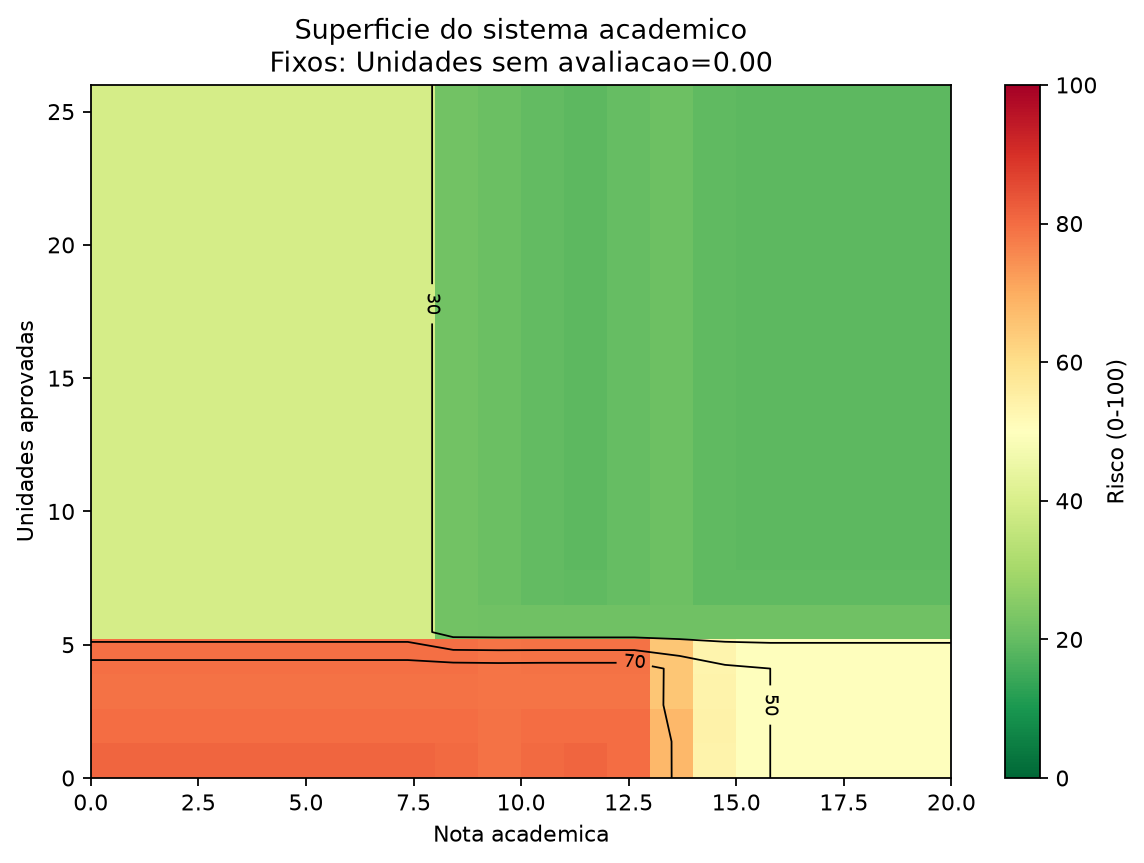

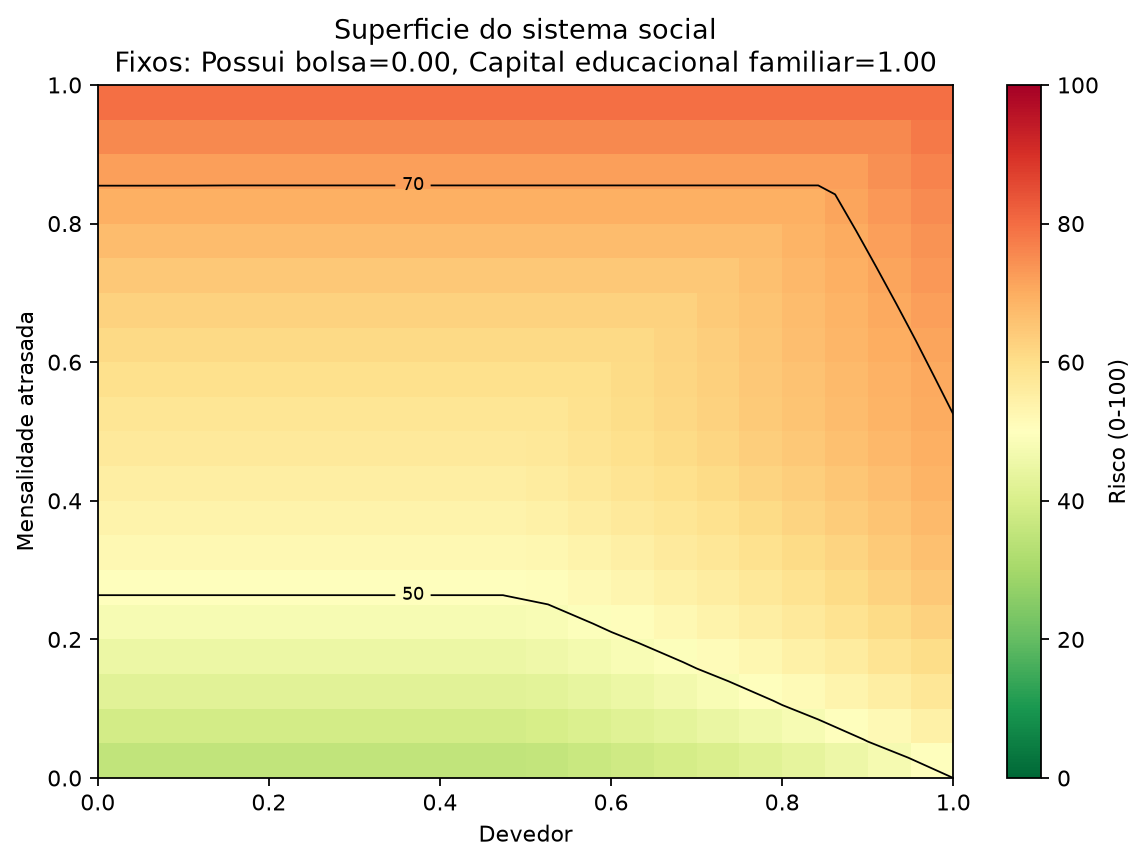

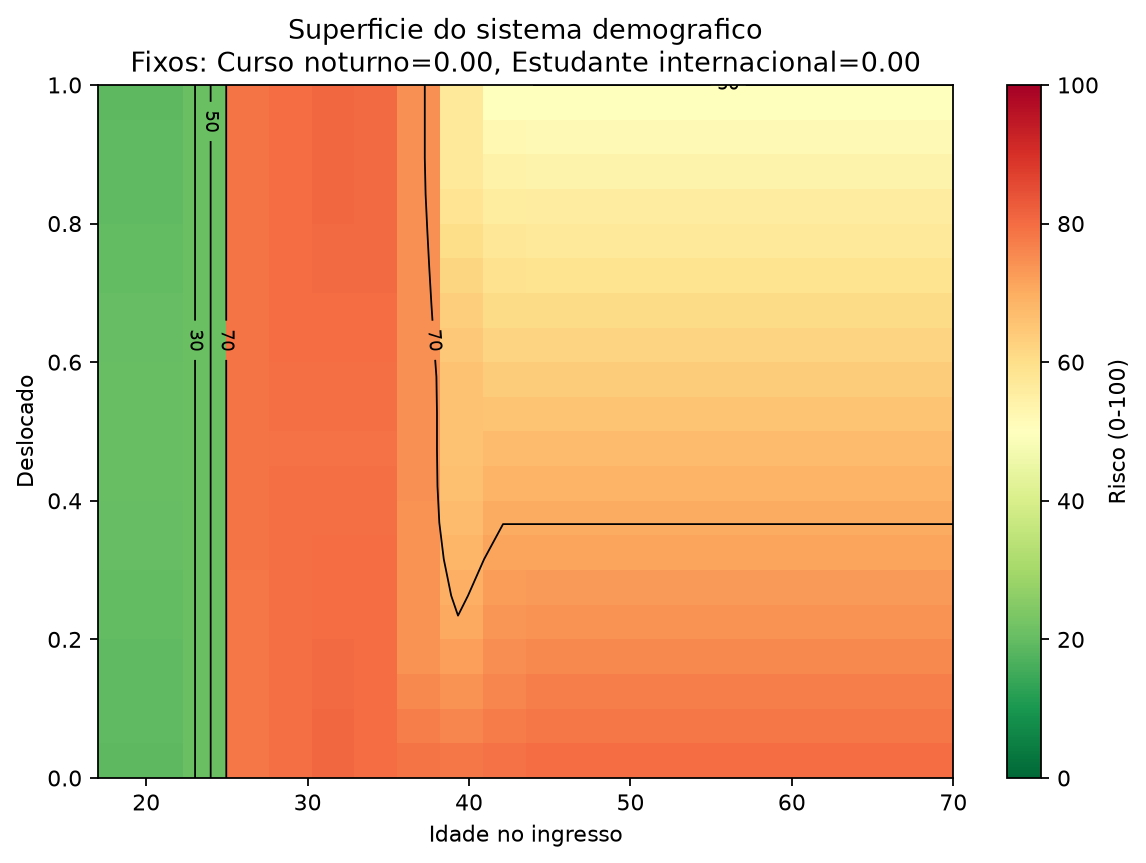

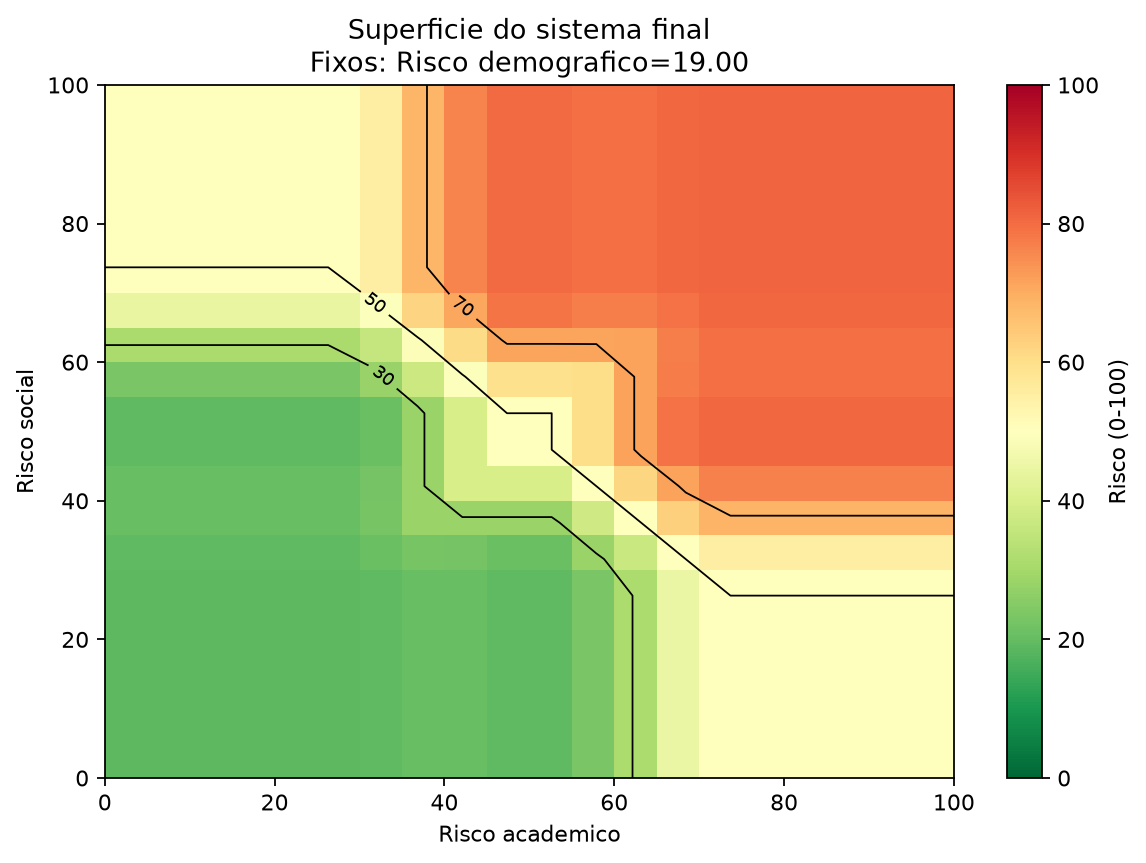

In [7]:
show_images([
    OUTPUT_DIR / 'heatmap_academico.png',
    OUTPUT_DIR / 'heatmap_social.png',
    OUTPUT_DIR / 'heatmap_demografico.png',
    OUTPUT_DIR / 'heatmap_final.png',
])

## 5. Seleção do limiar na validação

F2 atribui peso maior ao recall. Isso representa a prioridade de reduzir estudantes em risco que não receberiam atenção. O teste não participa desta escolha.

Limiar selecionado: 29


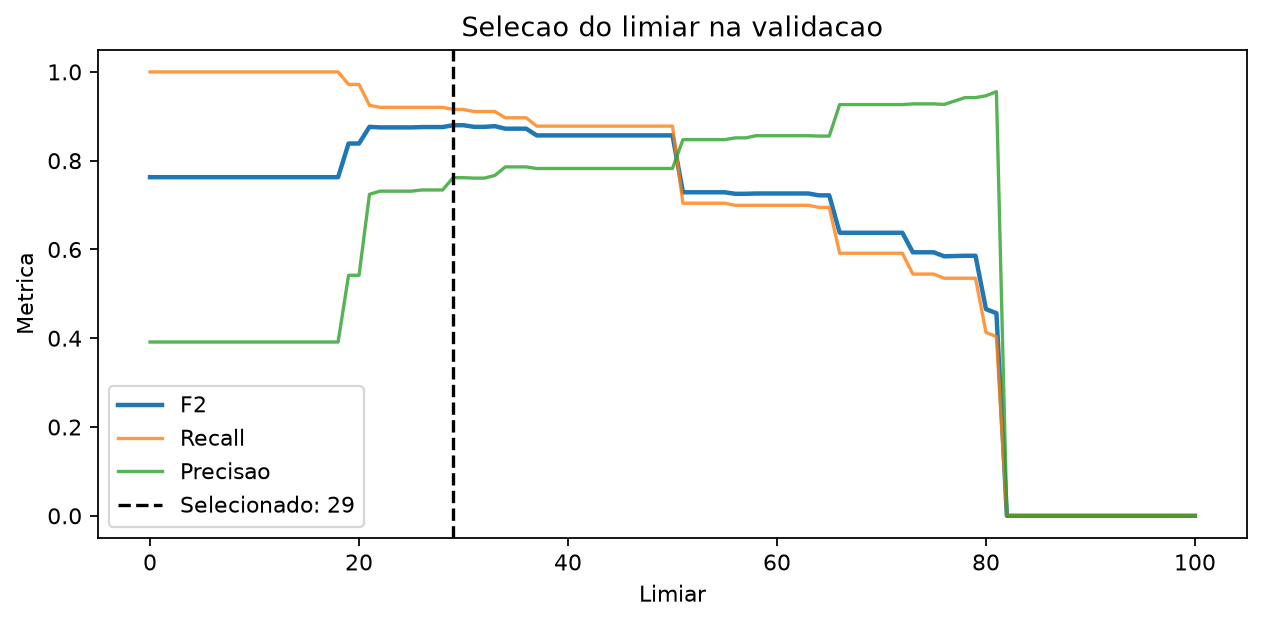

,threshold,precision_dropout,recall_dropout,f1_dropout,f2_dropout
21,21.0,0.724265,0.924883,0.812371,0.876335
22,22.0,0.731343,0.920188,0.814969,0.875000
26,26.0,0.734082,0.920188,0.816667,0.875782
27,27.0,0.734082,0.920188,0.816667,0.875782
28,28.0,0.734082,0.920188,0.816667,0.875782
29,29.0,0.761719,0.915493,0.831557,0.879964
30,30.0,0.761719,0.915493,0.831557,0.879964
31,31.0,0.760784,0.910798,0.829060,0.876242
32,32.0,0.760784,0.910798,0.829060,0.876242
33,33.0,0.766798,0.910798,0.832618,0.877828


In [8]:
validation_metrics = pd.DataFrame([item.to_dict() for item in experiment.validation_sweep])
print(f'Limiar selecionado: {experiment.selected_validation_metrics.threshold:.0f}')
show_images([OUTPUT_DIR / 'validation_f2_threshold.png'])
validation_metrics.loc[validation_metrics['f2_dropout'].nlargest(10).index, [
    'threshold', 'precision_dropout', 'recall_dropout', 'f1_dropout', 'f2_dropout'
]].sort_values('threshold')

## 6. Avaliação final no teste

Os números abaixo são calculados uma única vez na partição de teste. Os intervalos bootstrap expressam a incerteza amostral, sem transformar o resultado em garantia de desempenho fora deste dataset.

,teste
threshold,29.0
accuracy,0.831193
precision_dropout,0.753138
recall_dropout,0.84507
f1_dropout,0.79646
f2_dropout,0.824931
specificity,0.822289
balanced_accuracy,0.83368
roc_auc,0.909921
pr_auc,0.869503


,lower,upper
accuracy,0.798165,0.862385
precision_dropout,0.712047,0.797487
recall_dropout,0.788732,0.892019
f1_dropout,0.756620,0.832262
f2_dropout,0.778353,0.863803
specificity,0.783133,0.861446
balanced_accuracy,0.798978,0.864352
roc_auc,0.882077,0.933014
pr_auc,0.834523,0.900069


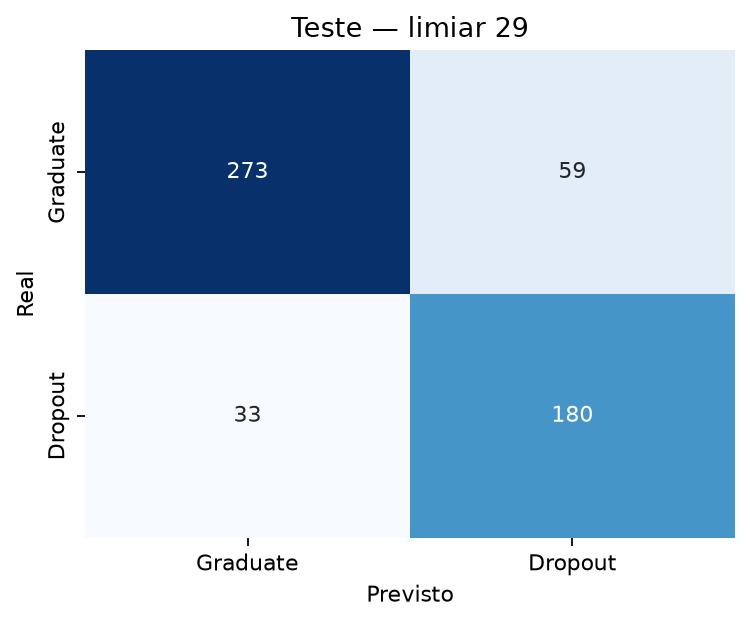

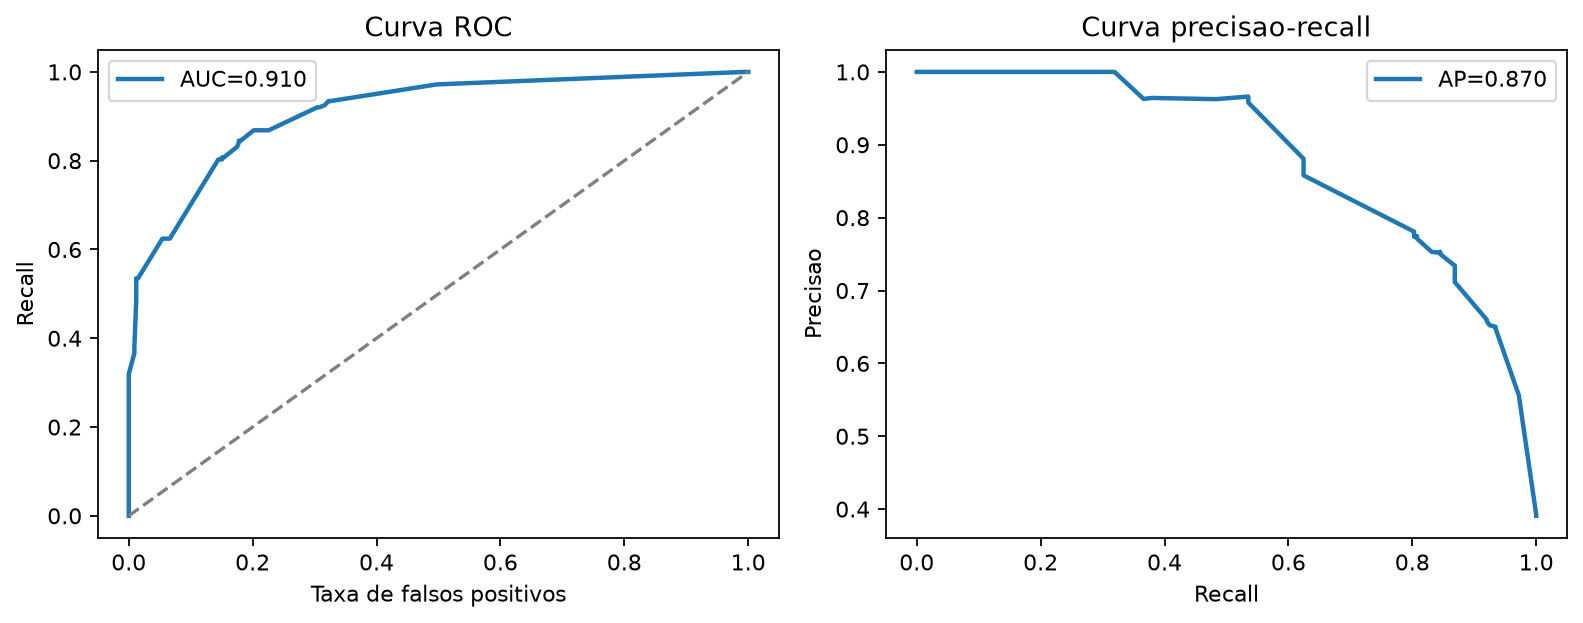

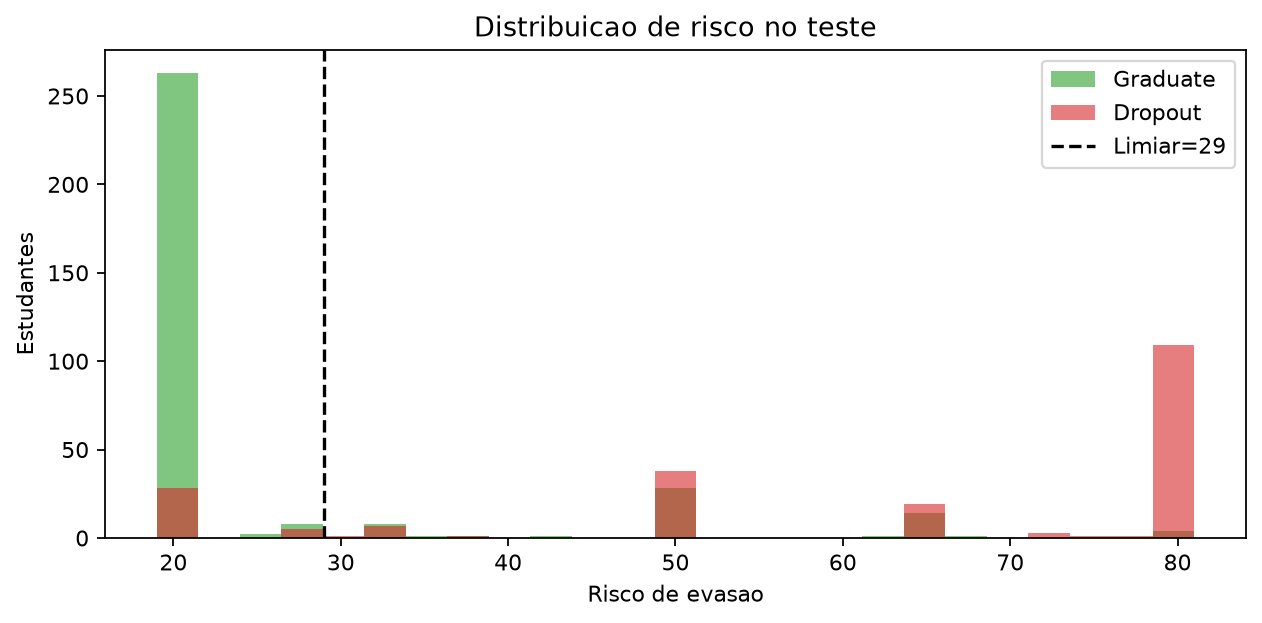

In [9]:
test_metrics = pd.Series(experiment.test_metrics.to_dict()).drop('confusion_matrix')
display(test_metrics.to_frame('teste'))
display(pd.DataFrame(experiment.confidence_intervals).T)
show_images([
    OUTPUT_DIR / 'confusion_matrix_test.png',
    OUTPUT_DIR / 'roc_pr_test.png',
    OUTPUT_DIR / 'risk_distribution_test.png',
])

## 7. Explicações individuais e análise de erros

São escolhidos o verdadeiro positivo, verdadeiro negativo, falso positivo e falso negativo de maior confiança, quando cada categoria existe. A explicação mostra os riscos intermediários e as regras que mais dispararam. Casos individuais ajudam a auditar o comportamento, mas não provam causalidade.


### Verdadeiro Positivo — row_id=39


,risco
risco_academico,79.279931
risco_social,81.000044
risco_demografico,18.999956
risco_evasao,81.000044


,sistema,regra,forca,suporte,risco_estimado
0,academico,SE nota_academica=media E aprovadas=medias E sem_avaliacao=poucas ENTAO risco=alto,0.489089,183.815204,66.004505
1,social,SE debtor=sim E tuition_late=sim E scholarship=nao E capital_educacional=alto ENTAO risco=alto,1.000000,27.000000,90.493408
2,demografico,SE idade=jovem E deslocado=nao E noturno=nao E internacional=sim ENTAO risco=baixo,1.000000,12.000000,18.575827
3,final,SE risco_academico=alto E risco_social=alto E risco_demografico=baixo ENTAO risco=alto,1.000000,98.817726,95.143306


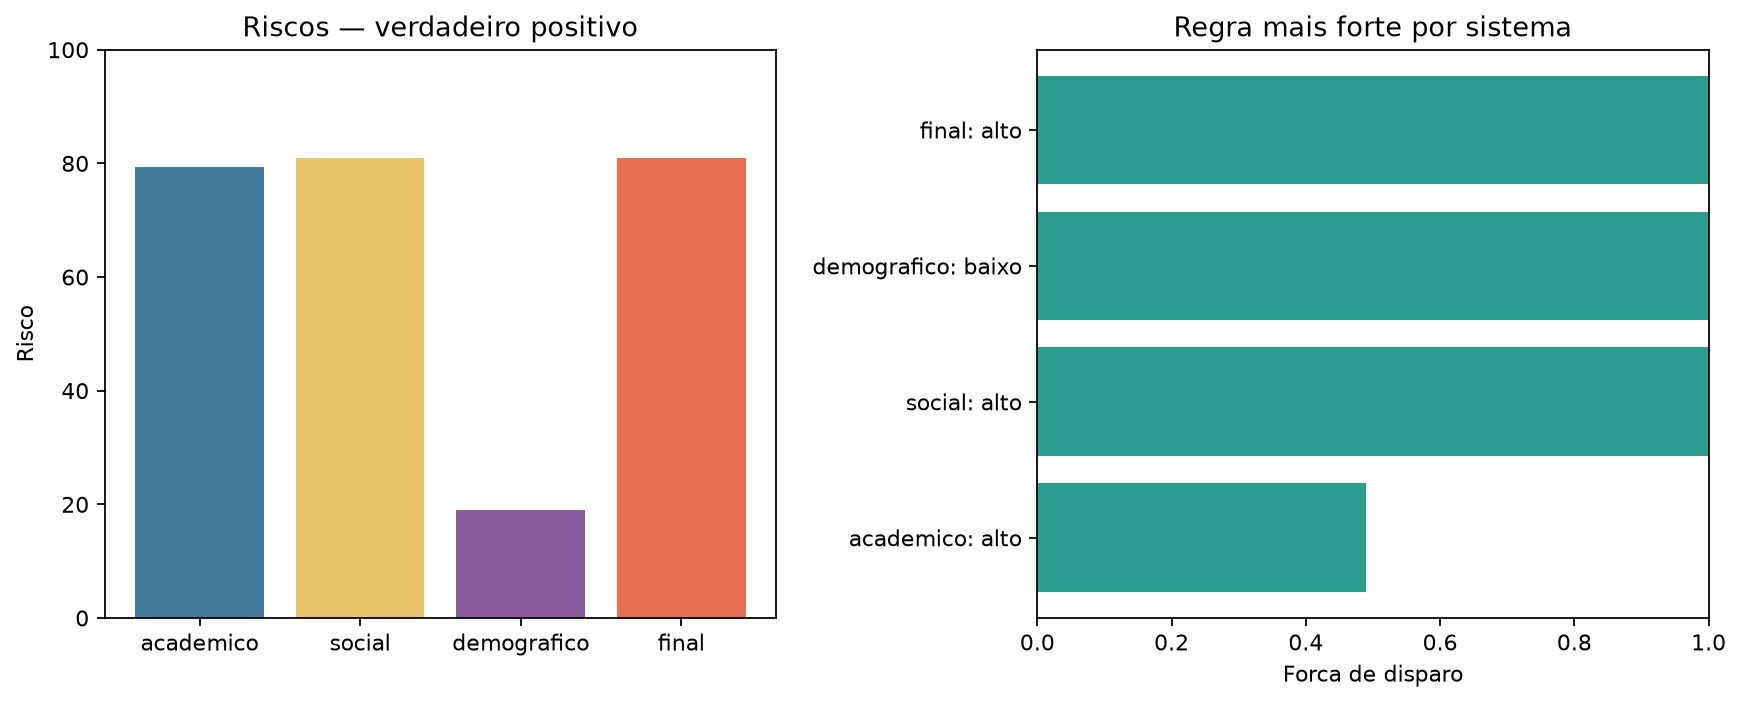


### Verdadeiro Negativo — row_id=2414


,risco
risco_academico,20.108221
risco_social,50.000000
risco_demografico,21.035675
risco_evasao,18.999956


,sistema,regra,forca,suporte,risco_estimado
0,academico,SE nota_academica=media E aprovadas=muitas E sem_avaliacao=medias ENTAO risco=baixo,0.665460,3.483413,34.866754
1,social,SE debtor=nao E tuition_late=nao E scholarship=nao E capital_educacional=baixo ENTAO risco=medio,0.670218,405.000000,43.404364
2,demografico,SE idade=jovem E deslocado=sim E noturno=nao E internacional=nao ENTAO risco=baixo,0.400000,1093.200000,28.406291
3,final,SE risco_academico=baixo E risco_social=medio E risco_demografico=baixo ENTAO risco=baixo,1.000000,115.073795,14.583805


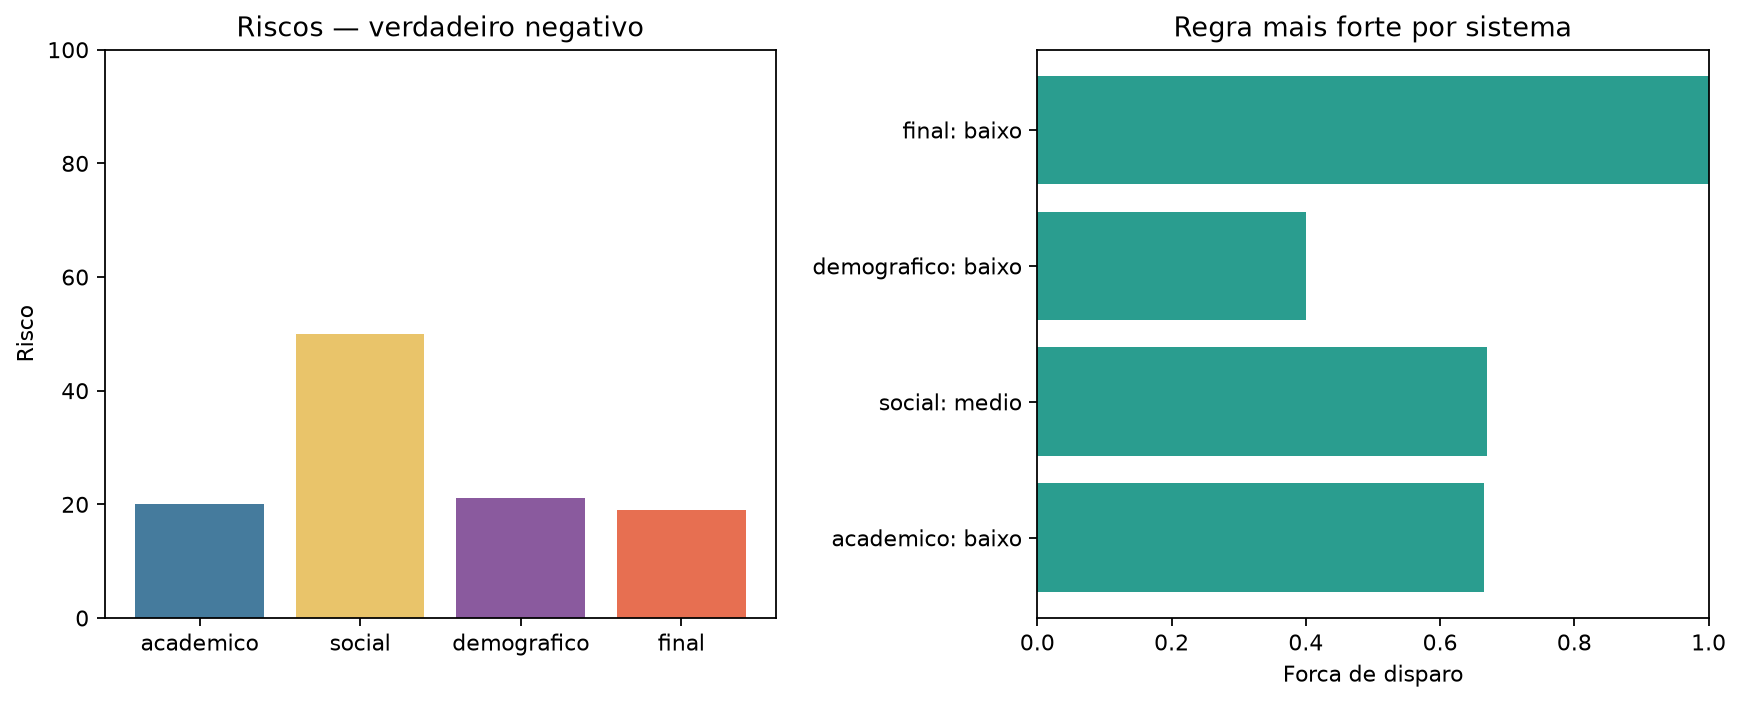


### Falso Positivo — row_id=1288


,risco
risco_academico,78.404228
risco_social,50.000000
risco_demografico,18.999956
risco_evasao,81.000044


,sistema,regra,forca,suporte,risco_estimado
0,academico,SE nota_academica=media E aprovadas=medias E sem_avaliacao=poucas ENTAO risco=alto,0.244545,183.815204,66.004505
1,social,SE debtor=nao E tuition_late=nao E scholarship=nao E capital_educacional=baixo ENTAO risco=medio,0.670218,405.000000,43.404364
2,demografico,SE idade=jovem E deslocado=sim E noturno=nao E internacional=nao ENTAO risco=baixo,1.000000,1093.200000,28.406291
3,final,SE risco_academico=alto E risco_social=medio E risco_demografico=baixo ENTAO risco=alto,1.000000,79.051192,79.591706


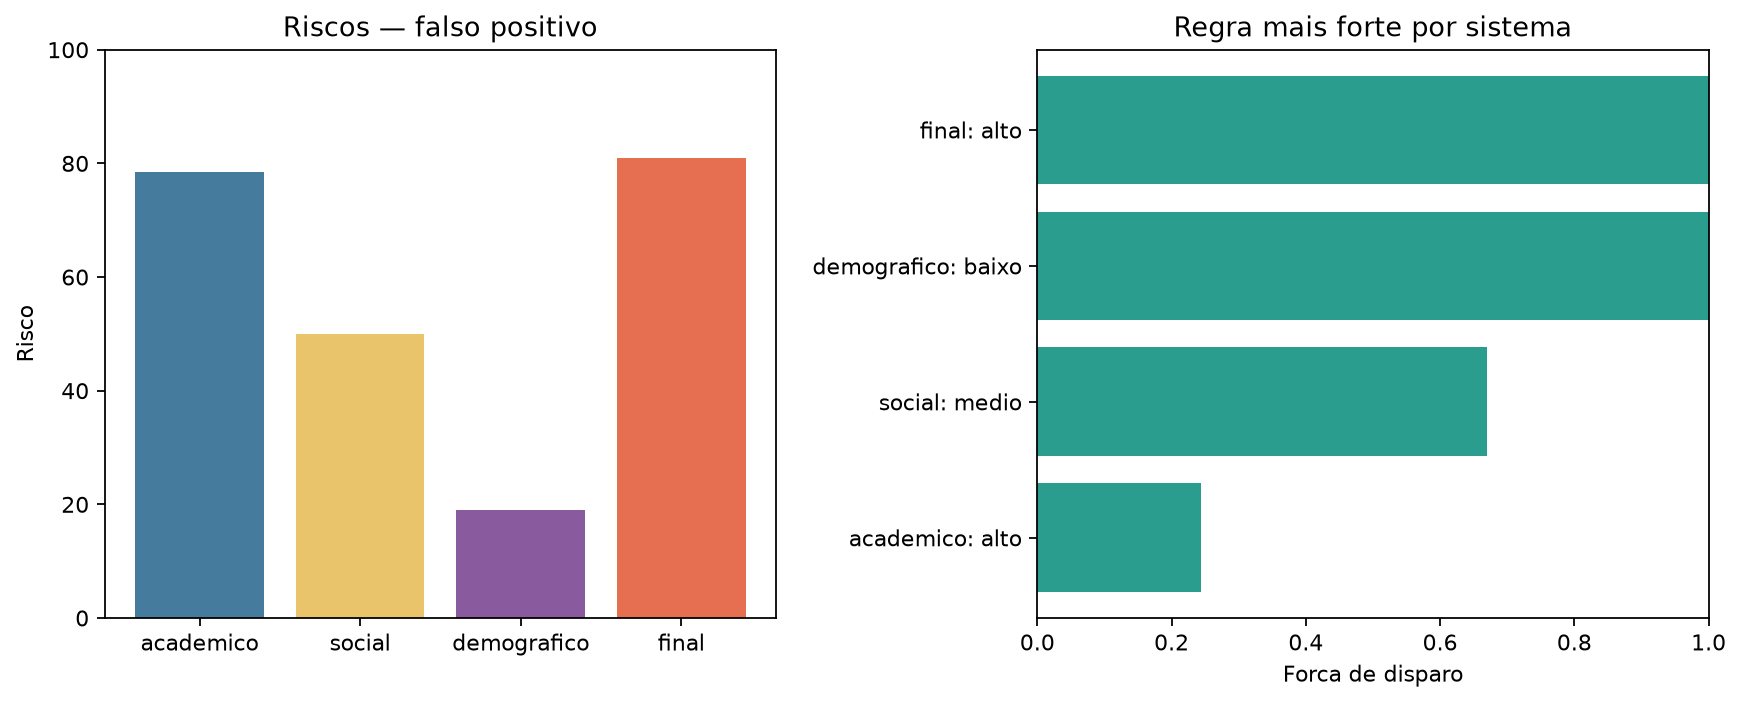


### Falso Negativo — row_id=552


,risco
risco_academico,20.681778
risco_social,50.000000
risco_demografico,19.653803
risco_evasao,18.999956


,sistema,regra,forca,suporte,risco_estimado
0,academico,SE nota_academica=media E aprovadas=muitas E sem_avaliacao=poucas ENTAO risco=baixo,0.500000,532.710793,10.948053
1,social,SE debtor=sim E tuition_late=nao E scholarship=nao E capital_educacional=alto ENTAO risco=medio,0.360009,25.500000,55.599641
2,social,SE debtor=sim E tuition_late=nao E scholarship=nao E capital_educacional=medio ENTAO risco=medio,0.337985,44.500000,56.480587
3,demografico,SE idade=jovem E deslocado=nao E noturno=nao E internacional=nao ENTAO risco=baixo,0.800000,512.000000,26.993789
4,final,SE risco_academico=baixo E risco_social=medio E risco_demografico=baixo ENTAO risco=baixo,1.000000,115.073795,14.583805


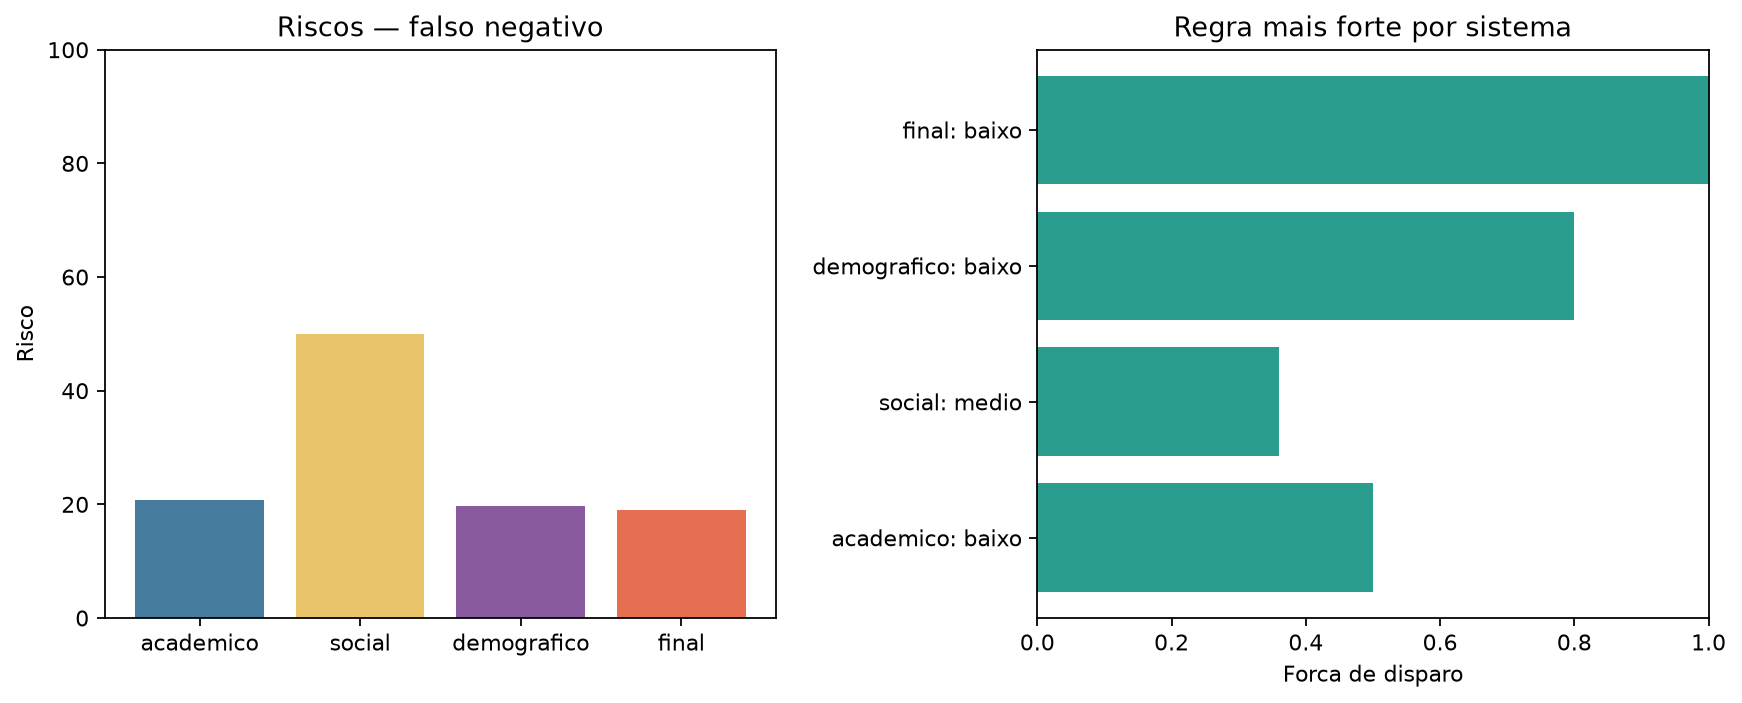

In [10]:
for case_name, explanation in experiment.explanations.items():
    print(f'\n### {case_name.replace("_", " ").title()} — row_id={experiment.representative_row_ids[case_name]}')
    display(pd.Series(explanation.risks).to_frame('risco'))
    rule_rows: list[dict[str, object]] = []
    for block_name, block in explanation.blocks.items():
        for activation in block.activations:
            rule_rows.append({
                'sistema': block_name, 'regra': activation.label,
                'forca': activation.firing_strength, 'suporte': activation.support,
                'risco_estimado': activation.estimated_risk,
            })
    display(pd.DataFrame(rule_rows))
    show_images([OUTPUT_DIR / f'case_{case_name}.png'])

## 8. Análise descritiva por subgrupos

A tabela procura diferenças que mereçam investigação. Grupos com menos de 30 estudantes são marcados como insuficientes. Esta análise não certifica justiça, ausência de viés ou relação causal.

In [11]:
experiment.subgroup_table.sort_values(['dimension', 'group'])

,dimension,group,n,sufficient,precision_dropout,recall_dropout,false_negative_rate,f2_dropout,accuracy
6,bolsa,0,414,True,0.781991,0.846154,0.153846,0.832492,0.816425
7,bolsa,1,131,True,0.535714,0.833333,0.166667,0.750000,0.877863
10,deslocado,0,229,True,0.837607,0.899083,0.100917,0.886076,0.868996
11,deslocado,1,316,True,0.672131,0.788462,0.211538,0.762082,0.803797
0,faixa_etaria,17-22,376,True,0.642336,0.800000,0.200000,0.762565,0.811170
1,faixa_etaria,23-30,78,True,0.934783,0.843137,0.156863,0.860000,0.858974
2,faixa_etaria,31-40,61,True,0.864865,0.941176,0.058824,0.924855,0.885246
3,faixa_etaria,41+,30,True,0.894737,0.944444,0.055556,0.934066,0.900000
8,internacional,0,532,True,0.747826,0.843137,0.156863,0.822180,0.830827
9,internacional,1,13,False,0.888889,0.888889,0.111111,0.888889,0.846154


## 9. Limitações e conclusão

- O estudo usa uma única instituição representada pelo dataset UCI; validação externa ainda é necessária.
- Os resultados são associações preditivas, não efeitos causais.
- O sistema usa informações obtidas durante o curso e apoia intervenção durante a trajetória, não seleção na admissão.
- Um risco alto deve iniciar acolhimento e análise humana, nunca uma punição ou decisão automática.
- A contribuição principal é combinar inferência Mamdani, regras aprendidas auditáveis, validação sem vazamento e explicações locais em um fluxo reproduzível.